# Job Scam Detection - Comparative Research Pipeline

This notebook compares BERT, ALBERT, and RoBERTa on the EMSCAD fake job posting dataset using repeated stratified holdout, multi-metric evaluation, statistical testing, learning curves, runtime logging, and paper-ready artifacts.

## 1. Setup and Configuration

In [1]:
import html
import inspect
import json
import math
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from torch.utils.data import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from transformers import EarlyStoppingCallback

try:
    import transformers
except ImportError as exc:
    raise ImportError("Install transformers before running this notebook.") from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)


In [2]:
PROJECT_ROOT = Path(".").resolve()
DATASET_PATH = PROJECT_ROOT / "fake_job_postings.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
RUNS_DIR = ARTIFACT_DIR / "runs"
SUMMARY_DIR = ARTIFACT_DIR / "summary"
FIGURES_DIR = ARTIFACT_DIR / "figures"
BEST_MODEL_DIR = PROJECT_ROOT / "best_model"

MODEL_REGISTRY = {
    "BERT": "bert-base-uncased",
    "ALBERT": "albert-base-v2",
    "RoBERTa": "roberta-base",
}

BASELINE_REGISTRY = {
    "TFIDF_LogReg": "TF-IDF + Logistic Regression",
    "TFIDF_LinearSVM": "TF-IDF + Linear SVM",
}

EXPERIMENT_SEEDS = [42, 123, 2024]
RUN_MODE = "full_multi_seed"  # options: "single_seed", "full_multi_seed"
SINGLE_SEED = 42
BASELINES_TO_RUN = ["TFIDF_LogReg", "TFIDF_LinearSVM"]
TRANSFORMERS_TO_RUN = ["BERT", "ALBERT", "RoBERTa"]
MODELS_TO_RUN = BASELINES_TO_RUN + TRANSFORMERS_TO_RUN
FORCE_RETRAIN = False
EVALUATE_TRAIN_EACH_EPOCH = True

CONFIG = {
    "max_len": 256,
    "batch_size": 16,
    "gradient_accumulation_steps": 1,
    "epochs": 5,
    "early_stopping_patience": 2,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "test_size": 0.15,
    "val_size": 0.15,
    "threshold_grid": np.round(np.arange(0.10, 0.91, 0.01), 2).tolist(),
    "score_threshold_quantiles": np.round(np.arange(0.01, 1.00, 0.01), 2).tolist(),
    "latency_sample_size": 128,
    "latency_repeats": 3,
    "bootstrap_iterations": 1000,
    "bootstrap_seed": 777,
}

for directory in [ARTIFACT_DIR, RUNS_DIR, SUMMARY_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_active_seeds() -> list[int]:
    if RUN_MODE == "single_seed":
        return [SINGLE_SEED]
    if RUN_MODE == "full_multi_seed":
        return EXPERIMENT_SEEDS
    raise ValueError(f"Unsupported RUN_MODE: {RUN_MODE}")


def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
    except ImportError:
        return False
    return True


def model_slug(model_label: str) -> str:
    return model_label.lower().replace(" ", "_")


def run_dir_for(seed: int, model_label: str) -> Path:
    return RUNS_DIR / f"seed_{seed}" / model_slug(model_label)


def get_all_model_labels() -> list[str]:
    return list(BASELINE_REGISTRY) + list(MODEL_REGISTRY)


def model_group_for(model_label: str) -> str:
    if model_label in BASELINE_REGISTRY:
        return "classical_baseline"
    if model_label in MODEL_REGISTRY:
        return "transformer"
    raise ValueError(f"Unknown model label: {model_label}")


def is_transformer_model(model_label: str) -> bool:
    return model_label in MODEL_REGISTRY


def make_json_safe(value):
    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_json_safe(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return None if not np.isfinite(value) else float(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(make_json_safe(payload), file, indent=2, ensure_ascii=False, allow_nan=False)


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


## 2. Environment and Reproducibility Log

In [5]:
def get_environment_info() -> dict:
    return {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "device": str(device),
        "created_at": datetime.now().isoformat(),
        "config": CONFIG,
        "experiment_seeds": EXPERIMENT_SEEDS,
        "models": MODEL_REGISTRY,
        "transformer_models": MODEL_REGISTRY,
        "baseline_models": BASELINE_REGISTRY,
        "models_to_run": MODELS_TO_RUN,
        "baselines_to_run": BASELINES_TO_RUN,
        "transformers_to_run": TRANSFORMERS_TO_RUN,
        "run_mode": RUN_MODE,
        "evaluate_train_each_epoch": EVALUATE_TRAIN_EACH_EPOCH,
    }


environment_info = get_environment_info()
write_json(ARTIFACT_DIR / "environment.json", environment_info)
environment_info


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35',
 'torch': '2.10.0+cu128',
 'transformers': '5.0.0',
 'cuda_available': True,
 'cuda_version': '12.8',
 'gpu_name': 'Tesla T4',
 'device': 'cuda',
 'created_at': '2026-05-01T09:37:50.714813',
 'config': {'max_len': 256,
  'batch_size': 16,
  'gradient_accumulation_steps': 1,
  'epochs': 5,
  'early_stopping_patience': 2,
  'learning_rate': 2e-05,
  'weight_decay': 0.01,
  'warmup_ratio': 0.1,
  'test_size': 0.15,
  'val_size': 0.15,
  'threshold_grid': [0.1,
   0.11,
   0.12,
   0.13,
   0.14,
   0.15,
   0.16,
   0.17,
   0.18,
   0.19,
   0.2,
   0.21,
   0.22,
   0.23,
   0.24,
   0.25,
   0.26,
   0.27,
   0.28,
   0.29,
   0.3,
   0.31,
   0.32,
   0.33,
   0.34,
   0.35,
   0.36,
   0.37,
   0.38,
   0.39,
   0.4,
   0.41,
   0.42,
   0.43,
   0.44,
   0.45,
   0.46,
   0.47,
   0.48,
   0.49,
   0.5,
   0.51,
   0.52,
   0.53,
   0.54,
   0.55,
   0.56,
   0.57,
 

## 3. Data Loading and Provenance

In [6]:
if running_in_colab() and not DATASET_PATH.exists():
    subprocess.run(
        ["gdown", "https://drive.google.com/uc?id=1-Bn_Ey676EijYC3zdzqMIrYgA2FAHaOh", "-O", "fake_job_postings.csv"],
        check=True,
    )


In [7]:
def load_emscad_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at {path}. Upload fake_job_postings.csv or run the Colab download cell."
        )
    df = pd.read_csv(path)
    expected_columns = {"job_id", "fraudulent", "title", "company_profile", "description", "requirements", "benefits"}
    missing_columns = sorted(expected_columns - set(df.columns))
    if missing_columns:
        raise ValueError(f"Dataset is missing required columns: {missing_columns}")
    return df


df_raw = load_emscad_dataset(DATASET_PATH)
print(f"Dataset shape: {df_raw.shape}")
print(f"Fraud rate: {df_raw['fraudulent'].mean() * 100:.2f}%")
df_raw.head()


Dataset shape: (17880, 18)
Fraud rate: 4.84%


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 4. EDA and Data Profile Export

In [8]:
TEXT_COLUMNS = ["title", "company_profile", "description", "requirements", "benefits"]
SUBGROUP_COLUMNS = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "industry",
    "function",
]


def build_data_profile(df: pd.DataFrame) -> dict:
    label_counts = df["fraudulent"].value_counts().sort_index()
    profile_columns = [column for column in TEXT_COLUMNS + SUBGROUP_COLUMNS if column in df.columns]
    missing_values = df[profile_columns].isna().sum().to_dict()
    return {
        "rows": int(len(df)),
        "columns": list(df.columns),
        "label_counts": {str(key): int(value) for key, value in label_counts.items()},
        "fraud_rate": float(df["fraudulent"].mean()),
        "missing_values": {key: int(value) for key, value in missing_values.items()},
    }


data_profile = build_data_profile(df_raw)
write_json(ARTIFACT_DIR / "data_profile.json", data_profile)
data_profile


{'rows': 17880,
 'columns': ['job_id',
  'title',
  'location',
  'department',
  'salary_range',
  'company_profile',
  'description',
  'requirements',
  'benefits',
  'telecommuting',
  'has_company_logo',
  'has_questions',
  'employment_type',
  'required_experience',
  'required_education',
  'industry',
  'function',
  'fraudulent'],
 'label_counts': {'0': 17014, '1': 866},
 'fraud_rate': 0.04843400447427293,
 'missing_values': {'title': 0,
  'company_profile': 3308,
  'description': 1,
  'requirements': 2696,
  'benefits': 7212,
  'telecommuting': 0,
  'has_company_logo': 0,
  'has_questions': 0,
  'employment_type': 3471,
  'required_experience': 7050,
  'industry': 4903,
  'function': 6455}}

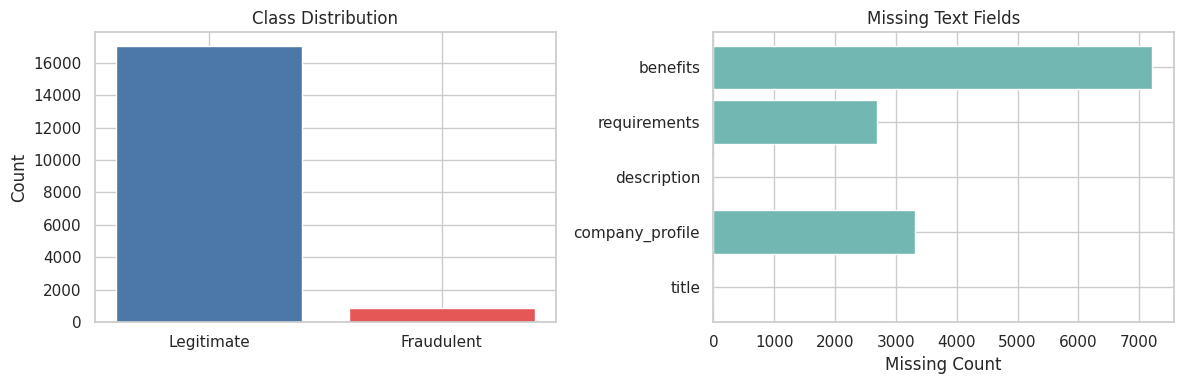

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts = df_raw["fraudulent"].value_counts().sort_index()
axes[0].bar(["Legitimate", "Fraudulent"], label_counts.values, color=["#4c78a8", "#e45756"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

missing_text = df_raw[TEXT_COLUMNS].isna().sum()
axes[1].barh(missing_text.index, missing_text.values, color="#72b7b2")
axes[1].set_title("Missing Text Fields")
axes[1].set_xlabel("Missing Count")

plt.tight_layout()
plt.show()


## 5. Text Preprocessing

In [10]:
def clean_text(text: str) -> str:
    """Clean and normalize text. This must match src/models/preprocessor.py."""
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def prepare_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()
    for column in TEXT_COLUMNS:
        prepared[column] = prepared[column].fillna("")
    prepared["text_raw"] = prepared[TEXT_COLUMNS].agg(" ".join, axis=1)
    prepared["text"] = prepared["text_raw"].apply(clean_text)
    prepared["text_length"] = prepared["text"].str.len()
    return prepared


df = prepare_text_columns(df_raw)
print(df[["job_id", "fraudulent", "text_length", "text"]].head())


   job_id  fraudulent  text_length  \
0       1           0         2657   
1       2           0         5715   
2       3           0         2634   
3       4           0         5458   
4       5           0         3859   

                                                text  
0  marketing intern we're food52, and we've creat...  
1  customer service - cloud video production 90 s...  
2  commissioning machinery assistant (cma) valor ...  
3  account executive - washington dc our passion ...  
4  bill review manager spotsource solutions llc i...  


## 6. Repeated Stratified Split Generation

In [11]:
def create_stratified_split(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_val_df, test_df = train_test_split(
        df,
        test_size=CONFIG["test_size"],
        stratify=df["fraudulent"],
        random_state=seed,
    )
    val_fraction = CONFIG["val_size"] / (1 - CONFIG["test_size"])
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_fraction,
        stratify=train_val_df["fraudulent"],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def summarize_split(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        rows.append(
            {
                "split": split_name,
                "rows": len(split_df),
                "fraud_count": int(split_df["fraudulent"].sum()),
                "fraud_rate": float(split_df["fraudulent"].mean()),
            }
        )
    return pd.DataFrame(rows)


preview_train_df, preview_val_df, preview_test_df = create_stratified_split(df, SINGLE_SEED)
summarize_split(preview_train_df, preview_val_df, preview_test_df)


,split,rows,fraud_count,fraud_rate
0,train,12516,606,0.048418
1,validation,2682,130,0.048471
2,test,2682,130,0.048471


## 7. Dataset Class

In [12]:
class JobPostingDataset(Dataset):
    def __init__(self, texts: pd.Series, labels: pd.Series, tokenizer, max_len: int):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict:
        encoding = self.tokenizer(
            str(self.texts[index]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(self.labels[index]), dtype=torch.long),
        }


## 8. Metrics Helpers

In [13]:
def safe_auc(metric_func, labels: np.ndarray, scores: np.ndarray) -> float:
    try:
        return float(metric_func(labels, scores))
    except ValueError:
        return float("nan")


def compute_binary_metrics(labels: np.ndarray, fraud_scores: np.ndarray, threshold: float = 0.50) -> dict:
    labels = np.asarray(labels).astype(int)
    fraud_scores = np.asarray(fraud_scores).astype(float)
    if labels.shape[0] != fraud_scores.shape[0]:
        raise ValueError("labels and fraud_scores must have the same length")
    if not np.all(np.isfinite(fraud_scores)):
        raise ValueError("fraud_scores contains non-finite values")
    predictions = (fraud_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, predictions)),
        "fraud_precision": float(precision_score(labels, predictions, zero_division=0)),
        "fraud_recall": float(recall_score(labels, predictions, zero_division=0)),
        "fraud_f1": float(f1_score(labels, predictions, zero_division=0)),
        "macro_f1": float(f1_score(labels, predictions, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "specificity": float(specificity),
        "roc_auc": safe_auc(roc_auc_score, labels, fraud_scores),
        "pr_auc": safe_auc(average_precision_score, labels, fraud_scores),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def build_threshold_candidates(fraud_scores: np.ndarray) -> list[float]:
    fraud_scores = np.asarray(fraud_scores).astype(float)
    fraud_scores = fraud_scores[np.isfinite(fraud_scores)]
    if fraud_scores.size == 0:
        return [0.50]
    if fraud_scores.min() >= 0.0 and fraud_scores.max() <= 1.0:
        return [float(threshold) for threshold in CONFIG["threshold_grid"]]
    quantiles = np.quantile(fraud_scores, CONFIG["score_threshold_quantiles"])
    candidates = sorted({float(value) for value in quantiles if np.isfinite(value)})
    if 0.0 >= fraud_scores.min() and 0.0 <= fraud_scores.max():
        candidates.append(0.0)
    return sorted(set(candidates))


def find_best_threshold(labels: np.ndarray, fraud_scores: np.ndarray) -> tuple[float, dict]:
    candidates = build_threshold_candidates(fraud_scores)
    best_threshold = candidates[0]
    best_metrics = compute_binary_metrics(labels, fraud_scores, best_threshold)
    for threshold in candidates[1:]:
        metrics = compute_binary_metrics(labels, fraud_scores, threshold)
        if metrics["fraud_f1"] > best_metrics["fraud_f1"]:
            best_threshold = float(threshold)
            best_metrics = metrics
    return best_threshold, best_metrics


def compute_trainer_metrics(eval_prediction) -> dict:
    logits, labels = eval_prediction
    fraud_probs = F.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    metrics = compute_binary_metrics(labels, fraud_probs, threshold=0.50)
    return {
        "accuracy": metrics["accuracy"],
        "fraud_precision": metrics["fraud_precision"],
        "fraud_recall": metrics["fraud_recall"],
        "fraud_f1": metrics["fraud_f1"],
        "macro_f1": metrics["macro_f1"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    }


## 9. Weighted Trainer and Training Runner

In [14]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_class_weights(train_df: pd.DataFrame) -> torch.Tensor:
    class_counts = train_df["fraudulent"].value_counts().sort_index()
    total = len(train_df)
    return torch.tensor(
        [total / (2 * class_counts[0]), total / (2 * class_counts[1])],
        dtype=torch.float32,
    )


In [15]:
def save_run_artifacts(
    run_dir: Path,
    config_payload: dict,
    runtime_payload: dict,
    default_metrics: dict,
    tuned_metrics: dict,
    predictions_df: pd.DataFrame,
    training_history_df: pd.DataFrame,
) -> None:
    run_dir.mkdir(parents=True, exist_ok=True)
    write_json(run_dir / "config.json", config_payload)
    write_json(run_dir / "runtime.json", runtime_payload)
    write_json(run_dir / "metrics_default_threshold.json", default_metrics)
    write_json(run_dir / "metrics_tuned_threshold.json", tuned_metrics)
    write_json(
        run_dir / "confusion_matrix.json",
        {"tn": default_metrics["tn"], "fp": default_metrics["fp"], "fn": default_metrics["fn"], "tp": default_metrics["tp"]},
    )
    predictions_df.to_csv(run_dir / "predictions.csv", index=False)
    training_history_df.to_csv(run_dir / "training_history.csv", index=False)


def trainer_history_to_frame(log_history: list[dict]) -> pd.DataFrame:
    rows = []
    for row in log_history:
        if "epoch" not in row:
            continue
        cleaned = {"epoch": row.get("epoch")}
        for key, value in row.items():
            if isinstance(value, (int, float, np.integer, np.floating)) and key != "epoch":
                cleaned[key] = float(value)
        rows.append(cleaned)
    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=["epoch"])


In [16]:
def build_predictions_frame(
    test_df: pd.DataFrame,
    fraud_scores: np.ndarray,
    threshold: float,
    score_type: str,
) -> pd.DataFrame:
    predictions = (fraud_scores >= threshold).astype(int)
    output_columns = [
        "job_id",
        "title",
        "company_profile",
        "description",
        "requirements",
        "benefits",
        "fraudulent",
    ]
    available_columns = [column for column in output_columns if column in test_df.columns]
    predictions_df = test_df[available_columns].copy()
    predictions_df["true_label"] = test_df["fraudulent"].astype(int).values
    predictions_df["fraud_score"] = np.asarray(fraud_scores).astype(float)
    predictions_df["fraud_probability"] = (
        np.asarray(fraud_scores).astype(float) if score_type == "probability" else np.nan
    )
    predictions_df["score_type"] = score_type
    predictions_df["threshold"] = float(threshold)
    predictions_df["predicted_label"] = predictions
    predictions_df["error_type"] = np.select(
        [
            (predictions_df["true_label"] == 0) & (predictions_df["predicted_label"] == 1),
            (predictions_df["true_label"] == 1) & (predictions_df["predicted_label"] == 0),
        ],
        ["FP", "FN"],
        default="correct",
    )
    return predictions_df


In [17]:
def build_training_arguments(output_dir: Path, seed: int, metric_for_best_model: str) -> TrainingArguments:
    kwargs = {
        "output_dir": str(output_dir),
        "num_train_epochs": CONFIG["epochs"],
        "per_device_train_batch_size": CONFIG["batch_size"],
        "per_device_eval_batch_size": CONFIG["batch_size"],
        "gradient_accumulation_steps": CONFIG["gradient_accumulation_steps"],
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "warmup_ratio": CONFIG["warmup_ratio"],
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": metric_for_best_model,
        "greater_is_better": True,
        "logging_strategy": "epoch",
        "save_total_limit": 1,
        "report_to": "none",
        "seed": seed,
        "fp16": torch.cuda.is_available(),
    }
    signature = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"
    return TrainingArguments(**kwargs)


def plot_single_run_learning_curves(history_df: pd.DataFrame, run_dir: Path, model_label: str, seed: int) -> None:
    if history_df.empty:
        return
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for axis, (title, columns) in zip(
        axes,
        [
            ("Loss", ["loss", "eval_validation_loss", "eval_train_loss"]),
            ("Accuracy", ["eval_validation_accuracy", "eval_train_accuracy"]),
            ("Fraud F1", ["eval_validation_fraud_f1", "eval_train_fraud_f1"]),
        ],
    ):
        for column in columns:
            if column in history_df.columns:
                curve = history_df[["epoch", column]].dropna()
                if not curve.empty:
                    axis.plot(curve["epoch"], curve[column], marker="o", label=column)
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.legend()
    fig.suptitle(f"{model_label} - Seed {seed}")
    fig.tight_layout()
    fig.savefig(run_dir / "learning_curves.png", dpi=200)
    plt.close(fig)


In [18]:
def train_and_evaluate(model_label: str, seed: int, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    set_seed(seed)
    hf_model_id = MODEL_REGISTRY[model_label]
    current_run_dir = run_dir_for(seed, model_label)
    completed_marker = current_run_dir / "metrics_tuned_threshold.json"

    if completed_marker.exists() and not FORCE_RETRAIN:
        print(f"Skipping completed run: seed={seed}, model={model_label}")
        return {"seed": seed, "model_label": model_label, "run_dir": str(current_run_dir), "status": "skipped"}

    start_time = time.time()
    started_at = datetime.now().isoformat()
    current_run_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(hf_model_id)
    model = AutoModelForSequenceClassification.from_pretrained(hf_model_id, num_labels=2)

    train_dataset = JobPostingDataset(train_df["text"], train_df["fraudulent"], tokenizer, CONFIG["max_len"])
    val_dataset = JobPostingDataset(val_df["text"], val_df["fraudulent"], tokenizer, CONFIG["max_len"])
    test_dataset = JobPostingDataset(test_df["text"], test_df["fraudulent"], tokenizer, CONFIG["max_len"])

    eval_dataset = {"validation": val_dataset}
    if EVALUATE_TRAIN_EACH_EPOCH:
        eval_dataset["train"] = train_dataset

    trainer = WeightedTrainer(
        class_weights=compute_class_weights(train_df),
        model=model,
        args=build_training_arguments(current_run_dir / "trainer_output", seed, "eval_validation_fraud_f1"),
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_trainer_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=CONFIG["early_stopping_patience"],
                early_stopping_threshold=0.0,
            )
        ],
    )
    trainer.train()

    val_output = trainer.predict(val_dataset)
    test_output = trainer.predict(test_dataset)
    latency_count = min(CONFIG["latency_sample_size"], len(test_dataset))
    latency_dataset = torch.utils.data.Subset(test_dataset, list(range(latency_count)))
    latency_seconds = []
    for _ in range(CONFIG["latency_repeats"]):
        latency_start = time.time()
        trainer.predict(latency_dataset)
        latency_seconds.append(time.time() - latency_start)
    latency_payload = summarize_latency_seconds(latency_seconds, latency_count)
    val_probs = F.softmax(torch.tensor(val_output.predictions), dim=-1).numpy()[:, 1]
    test_probs = F.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()[:, 1]
    val_labels = val_df["fraudulent"].astype(int).values
    test_labels = test_df["fraudulent"].astype(int).values

    tuned_threshold, validation_tuned_metrics = find_best_threshold(val_labels, val_probs)
    default_metrics = compute_binary_metrics(test_labels, test_probs, threshold=0.50)
    tuned_metrics = compute_binary_metrics(test_labels, test_probs, threshold=tuned_threshold)
    tuned_metrics["validation_selected_threshold"] = float(tuned_threshold)
    tuned_metrics["validation_fraud_f1_at_threshold"] = float(validation_tuned_metrics["fraud_f1"])

    predictions_df = build_predictions_frame(test_df, test_probs, tuned_threshold, "probability")
    training_history_df = trainer_history_to_frame(trainer.state.log_history)

    model_dir = current_run_dir / "model"
    trainer.save_model(str(model_dir))
    tokenizer.save_pretrained(str(model_dir))

    total_seconds = time.time() - start_time
    runtime_payload = {
        "seed": seed,
        "model_label": model_label,
        "model_group": model_group_for(model_label),
        "hf_model_id": hf_model_id,
        "early_stopping_patience": CONFIG["early_stopping_patience"],
        "score_type": "probability",
        "started_at": started_at,
        "ended_at": datetime.now().isoformat(),
        "total_seconds": float(total_seconds),
        "total_minutes": float(total_seconds / 60),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "cuda_available": torch.cuda.is_available(),
        "batch_size": CONFIG["batch_size"],
        "gradient_accumulation_steps": CONFIG["gradient_accumulation_steps"],
        "effective_batch_size": CONFIG["batch_size"] * CONFIG["gradient_accumulation_steps"],
        "fp16": torch.cuda.is_available(),
        "epochs": CONFIG["epochs"],
        "max_len": CONFIG["max_len"],
    }
    runtime_payload.update(latency_payload)
    config_payload = {
        "seed": seed,
        "model_label": model_label,
        "hf_model_id": hf_model_id,
        "config": CONFIG,
        "evaluate_train_each_epoch": EVALUATE_TRAIN_EACH_EPOCH,
    }
    save_run_artifacts(current_run_dir, config_payload, runtime_payload, default_metrics, tuned_metrics, predictions_df, training_history_df)
    plot_single_run_learning_curves(training_history_df, current_run_dir, model_label, seed)

    return {
        "seed": seed,
        "model_label": model_label,
        "run_dir": str(current_run_dir),
        "status": "completed",
        "fraud_f1": tuned_metrics["fraud_f1"],
        "pr_auc": tuned_metrics["pr_auc"],
        "runtime_minutes": runtime_payload["total_minutes"],
    }


In [19]:
def build_baseline_pipeline(model_label: str, seed: int) -> Pipeline:
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        sublinear_tf=True,
    )
    if model_label == "TFIDF_LogReg":
        classifier = LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="liblinear",
            random_state=seed,
        )
    elif model_label == "TFIDF_LinearSVM":
        classifier = LinearSVC(class_weight="balanced", random_state=seed)
    else:
        raise ValueError(f"Unsupported baseline model: {model_label}")
    return Pipeline([("tfidf", vectorizer), ("classifier", classifier)])


def score_baseline_model(pipeline: Pipeline, texts: pd.Series | list[str]) -> tuple[np.ndarray, str]:
    if hasattr(pipeline, "predict_proba"):
        scores = pipeline.predict_proba(texts)[:, 1]
        return np.asarray(scores).astype(float), "probability"
    scores = pipeline.decision_function(texts)
    return np.asarray(scores).astype(float), "decision_function"


def train_and_evaluate_baseline(
    model_label: str,
    seed: int,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict:
    set_seed(seed)
    current_run_dir = run_dir_for(seed, model_label)
    completed_marker = current_run_dir / "metrics_tuned_threshold.json"

    if completed_marker.exists() and not FORCE_RETRAIN:
        print(f"Skipping completed run: seed={seed}, model={model_label}")
        return {"seed": seed, "model_label": model_label, "run_dir": str(current_run_dir), "status": "skipped"}

    start_time = time.time()
    started_at = datetime.now().isoformat()
    current_run_dir.mkdir(parents=True, exist_ok=True)

    pipeline = build_baseline_pipeline(model_label, seed)
    pipeline.fit(train_df["text"], train_df["fraudulent"].astype(int))

    val_scores, score_type = score_baseline_model(pipeline, val_df["text"])
    test_scores, _ = score_baseline_model(pipeline, test_df["text"])
    latency_texts = test_df["text"].head(CONFIG["latency_sample_size"])
    latency_seconds = []
    for _ in range(CONFIG["latency_repeats"]):
        latency_start = time.time()
        score_baseline_model(pipeline, latency_texts)
        latency_seconds.append(time.time() - latency_start)
    latency_payload = summarize_latency_seconds(latency_seconds, len(latency_texts))
    val_labels = val_df["fraudulent"].astype(int).values
    test_labels = test_df["fraudulent"].astype(int).values

    tuned_threshold, validation_tuned_metrics = find_best_threshold(val_labels, val_scores)
    default_threshold = 0.50 if score_type == "probability" else 0.0
    default_metrics = compute_binary_metrics(test_labels, test_scores, threshold=default_threshold)
    tuned_metrics = compute_binary_metrics(test_labels, test_scores, threshold=tuned_threshold)
    tuned_metrics["validation_selected_threshold"] = float(tuned_threshold)
    tuned_metrics["validation_fraud_f1_at_threshold"] = float(validation_tuned_metrics["fraud_f1"])

    predictions_df = build_predictions_frame(test_df, test_scores, tuned_threshold, score_type)
    training_history_df = pd.DataFrame(columns=["epoch"])

    total_seconds = time.time() - start_time
    runtime_payload = {
        "seed": seed,
        "model_label": model_label,
        "model_group": model_group_for(model_label),
        "started_at": started_at,
        "ended_at": datetime.now().isoformat(),
        "total_seconds": float(total_seconds),
        "total_minutes": float(total_seconds / 60),
        "score_type": score_type,
        "epochs": None,
        "max_len": None,
    }
    runtime_payload.update(latency_payload)
    config_payload = {
        "seed": seed,
        "model_label": model_label,
        "model_group": model_group_for(model_label),
        "baseline_description": BASELINE_REGISTRY[model_label],
        "config": CONFIG,
    }
    save_run_artifacts(
        current_run_dir,
        config_payload,
        runtime_payload,
        default_metrics,
        tuned_metrics,
        predictions_df,
        training_history_df,
    )

    return {
        "seed": seed,
        "model_label": model_label,
        "run_dir": str(current_run_dir),
        "status": "completed",
        "fraud_f1": tuned_metrics["fraud_f1"],
        "pr_auc": tuned_metrics["pr_auc"],
        "runtime_minutes": runtime_payload["total_minutes"],
    }


def train_and_evaluate_any_model(
    model_label: str,
    seed: int,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict:
    if model_label in BASELINE_REGISTRY:
        return train_and_evaluate_baseline(model_label, seed, train_df, val_df, test_df)
    if model_label in MODEL_REGISTRY:
        return train_and_evaluate(model_label, seed, train_df, val_df, test_df)
    raise ValueError(f"Unknown model label: {model_label}")


In [20]:
def compute_directory_size_mb(path: Path) -> float | None:
    if not path.exists():
        return None
    total_bytes = sum(file_path.stat().st_size for file_path in path.rglob("*") if file_path.is_file())
    return float(total_bytes / (1024 * 1024))


def summarize_latency_seconds(latencies: list[float], sample_count: int) -> dict:
    if not latencies or sample_count == 0:
        return {"inference_latency_ms_per_sample_mean": None, "inference_latency_ms_per_sample_std": None}
    per_sample_ms = np.asarray(latencies, dtype=float) * 1000.0 / sample_count
    return {
        "inference_latency_ms_per_sample_mean": float(per_sample_ms.mean()),
        "inference_latency_ms_per_sample_std": float(per_sample_ms.std(ddof=0)),
    }


## 10. Execute Resumable Experiments

In [21]:
experiment_results = []

for seed in get_active_seeds():
    train_df, val_df, test_df = create_stratified_split(df, seed)
    seed_dir = RUNS_DIR / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    split_summary = summarize_split(train_df, val_df, test_df)
    split_summary.to_csv(seed_dir / "split_summary.csv", index=False)
    print(f"\nSeed {seed} split summary")
    display(split_summary)

    for model_label in MODELS_TO_RUN:
        print(f"\nRunning seed={seed}, model={model_label}")
        result = train_and_evaluate_any_model(model_label, seed, train_df, val_df, test_df)
        experiment_results.append(result)

pd.DataFrame(experiment_results)



Seed 42 split summary


,split,rows,fraud_count,fraud_rate
0,train,12516,606,0.048418
1,validation,2682,130,0.048471
2,test,2682,130,0.048471



Running seed=42, model=TFIDF_LogReg

Running seed=42, model=TFIDF_LinearSVM

Running seed=42, model=BERT


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

early stopping required metric_for_best_model, but did not find eval_validation_fraud_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,seed,model_label,run_dir,status,fraud_f1,pr_auc,runtime_minutes
0,42,TFIDF_LogReg,/content/artifacts/runs/seed_42/tfidf_logreg,completed,0.877470,0.931171,0.256207
1,42,TFIDF_LinearSVM,/content/artifacts/runs/seed_42/tfidf_linearsvm,completed,0.919355,0.947907,0.261167
2,42,BERT,/content/artifacts/runs/seed_42/bert,completed,0.888889,0.944155,27.204615
3,42,ALBERT,/content/artifacts/runs/seed_42/albert,completed,0.855967,0.914834,32.496909
4,42,RoBERTa,/content/artifacts/runs/seed_42/roberta,completed,0.869231,0.931505,28.550983
5,123,TFIDF_LogReg,/content/artifacts/runs/seed_123/tfidf_logreg,completed,0.846154,0.914307,0.295016
6,123,TFIDF_LinearSVM,/content/artifacts/runs/seed_123/tfidf_linearsvm,completed,0.867769,0.931213,0.295976
7,123,BERT,/content/artifacts/runs/seed_123/bert,completed,0.842975,0.901447,29.026347
8,123,ALBERT,/content/artifacts/runs/seed_123/albert,completed,0.788136,0.873064,32.770155
9,123,RoBERTa,/content/artifacts/runs/seed_123/roberta,completed,0.807843,0.883281,21.934262


## 11. Aggregate Evaluation

In [22]:
def load_completed_run(seed: int, model_label: str) -> dict | None:
    current_run_dir = run_dir_for(seed, model_label)
    default_path = current_run_dir / "metrics_default_threshold.json"
    tuned_path = current_run_dir / "metrics_tuned_threshold.json"
    runtime_path = current_run_dir / "runtime.json"
    if not (default_path.exists() and tuned_path.exists() and runtime_path.exists()):
        return None
    default_metrics = read_json(default_path)
    tuned_metrics = read_json(tuned_path)
    runtime_metrics = read_json(runtime_path)
    row = {
        "seed": seed,
        "model_label": model_label,
        "model_group": model_group_for(model_label),
        "run_dir": str(current_run_dir),
        "default_threshold": default_metrics["threshold"],
        "tuned_threshold": tuned_metrics["threshold"],
        "runtime_minutes": runtime_metrics["total_minutes"],
        "score_type": runtime_metrics.get("score_type"),
    }
    for key, value in default_metrics.items():
        row[f"default_{key}"] = value
    for key, value in tuned_metrics.items():
        row[f"tuned_{key}"] = value
    return row


def aggregate_completed_runs() -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for seed in EXPERIMENT_SEEDS:
        for model_label in get_all_model_labels():
            loaded = load_completed_run(seed, model_label)
            if loaded is not None:
                rows.append(loaded)
    all_runs_df = pd.DataFrame(rows)
    all_runs_df.to_csv(SUMMARY_DIR / "all_runs.csv", index=False)

    if all_runs_df.empty:
        empty_summary = pd.DataFrame()
        empty_summary.to_csv(SUMMARY_DIR / "mean_std_by_model.csv")
        return all_runs_df, empty_summary

    default_columns = [column for column in all_runs_df.columns if column.startswith("default_")]
    tuned_columns = [column for column in all_runs_df.columns if column.startswith("tuned_")]
    all_runs_df[["seed", "model_label"] + default_columns].to_csv(SUMMARY_DIR / "default_threshold_metrics.csv", index=False)
    all_runs_df[["seed", "model_label"] + tuned_columns].to_csv(SUMMARY_DIR / "tuned_threshold_metrics.csv", index=False)

    metric_columns = [
        "tuned_accuracy",
        "tuned_fraud_precision",
        "tuned_fraud_recall",
        "tuned_fraud_f1",
        "tuned_macro_f1",
        "tuned_balanced_accuracy",
        "tuned_specificity",
        "tuned_roc_auc",
        "tuned_pr_auc",
        "runtime_minutes",
    ]
    summary_df = (
        all_runs_df.groupby(["model_group", "model_label"])[metric_columns]
        .agg(["mean", "std"])
        .sort_values(("tuned_fraud_f1", "mean"), ascending=False)
    )
    summary_df.to_csv(SUMMARY_DIR / "mean_std_by_model.csv")
    all_runs_df[["seed", "model_group", "model_label", "runtime_minutes"]].to_csv(
        SUMMARY_DIR / "runtime_by_model.csv",
        index=False,
    )
    return all_runs_df, summary_df


all_runs_df, mean_std_by_model = aggregate_completed_runs()
display(all_runs_df)
display(mean_std_by_model)


,seed,model_label,model_group,run_dir,default_threshold,tuned_threshold,runtime_minutes,score_type,default_accuracy,default_fraud_precision,default_fraud_recall,default_fraud_f1,default_macro_f1,default_balanced_accuracy,default_specificity,default_roc_auc,default_pr_auc,default_tn,default_fp,default_fn,default_tp,tuned_accuracy,tuned_fraud_precision,tuned_fraud_recall,tuned_fraud_f1,tuned_macro_f1,tuned_balanced_accuracy,tuned_specificity,tuned_roc_auc,tuned_pr_auc,tuned_tn,tuned_fp,tuned_fn,tuned_tp,tuned_validation_selected_threshold,tuned_validation_fraud_f1_at_threshold
0,42,TFIDF_LogReg,classical_baseline,/content/artifacts/runs/seed_42/tfidf_logreg,0.5,0.590000,0.256207,probability,0.986577,0.840580,0.892308,0.865672,0.929304,0.941844,0.991379,0.989146,0.931171,2530,22,14,116,0.988441,0.902439,0.853846,0.877470,0.935703,0.924572,0.995298,0.989146,0.931171,2540,12,19,111,0.590000,0.857143
1,42,TFIDF_LinearSVM,classical_baseline,/content/artifacts/runs/seed_42/tfidf_linearsvm,0.0,0.000000,0.261167,decision_function,0.992543,0.966102,0.876923,0.919355,0.957723,0.937678,0.998433,0.991087,0.947907,2548,4,16,114,0.992543,0.966102,0.876923,0.919355,0.957723,0.937678,0.998433,0.991087,0.947907,2548,4,16,114,0.000000,0.886179
2,42,BERT,transformer,/content/artifacts/runs/seed_42/bert,0.5,0.720000,27.204615,probability,0.990306,0.948276,0.846154,0.894309,0.944614,0.921901,0.997649,0.991976,0.944155,2546,6,20,110,0.989933,0.955752,0.830769,0.888889,0.941808,0.914405,0.998041,0.991976,0.944155,2547,5,22,108,0.720000,0.880658
3,42,ALBERT,transformer,/content/artifacts/runs/seed_42/albert,0.5,0.230000,32.496909,probability,0.988069,0.953704,0.792308,0.865546,0.929652,0.895174,0.998041,0.990425,0.914834,2547,5,27,103,0.986950,0.920354,0.800000,0.855967,0.924566,0.898237,0.996473,0.990425,0.914834,2543,9,26,104,0.230000,0.861660
4,42,RoBERTa,transformer,/content/artifacts/runs/seed_42/roberta,0.5,0.210000,28.550983,probability,0.986950,0.874016,0.853846,0.863813,0.928480,0.923788,0.993730,0.992906,0.931505,2536,16,19,111,0.987323,0.869231,0.869231,0.869231,0.931285,0.931285,0.993339,0.992906,0.931505,2535,17,17,113,0.210000,0.860465
5,123,TFIDF_LogReg,classical_baseline,/content/artifacts/runs/seed_123/tfidf_logreg,0.5,0.530000,0.295016,probability,0.984713,0.834586,0.853846,0.844106,0.918034,0.922613,0.991379,0.988663,0.914307,2530,22,19,111,0.985086,0.846154,0.846154,0.846154,0.919158,0.919158,0.992163,0.988663,0.914307,2532,20,20,110,0.530000,0.840000
6,123,TFIDF_LinearSVM,classical_baseline,/content/artifacts/runs/seed_123/tfidf_linearsvm,0.0,-0.032525,0.295976,decision_function,0.988441,0.954128,0.800000,0.870293,0.932122,0.899020,0.998041,0.988868,0.931213,2547,5,26,104,0.988069,0.937500,0.807692,0.867769,0.930761,0.902475,0.997257,0.988868,0.931213,2545,7,25,105,-0.032525,0.865546
7,123,BERT,transformer,/content/artifacts/runs/seed_123/bert,0.5,0.330000,29.026347,probability,0.985831,0.910714,0.784615,0.842975,0.917778,0.890348,0.996082,0.986213,0.901447,2542,10,28,102,0.985831,0.910714,0.784615,0.842975,0.917778,0.890348,0.996082,0.986213,0.901447,2542,10,28,102,0.330000,0.887967
8,123,ALBERT,transformer,/content/artifacts/runs/seed_123/albert,0.5,0.900000,32.770155,probability,0.981357,0.857143,0.738462,0.793388,0.891813,0.866096,0.993730,0.969861,0.873064,2536,16,34,96,0.981357,0.877358,0.715385,0.788136,0.889193,0.855145,0.994906,0.969861,0.873064,2539,13,37,93,0.900000,0.836066
9,123,RoBERTa,transformer,/content/artifacts/runs/seed_123/roberta,0.5,0.180000,21.934262,probability,0.983594,0.864407,0.784615,0.822581,0.906990,0.889173,0.993730,0.979457,0.883281,2536,16,28,102,0.981730,0.824000,0.792308,0.807843,0.899126,0.891844,0.991379,0.979457,0.883281,2530,22,27,103,0.180000,0.870588


tuned_accuracy            \
                                             mean       std   
model_group        model_label                                
classical_baseline TFIDF_LinearSVM       0.990554  0.002278   
transformer        BERT                  0.988566  0.002368   
classical_baseline TFIDF_LogReg          0.986577  0.001709   
transformer        RoBERTa               0.985831  0.003596   
                   ALBERT                0.985334  0.003464   

                                   tuned_fraud_precision            \
                                                    mean       std   
model_group        model_label                                       
classical_baseline TFIDF_LinearSVM              0.950918  0.014382   
transformer        BERT                         0.933080  0.022521   
classical_baseline TFIDF_LogReg                 0.862670  0.034606   
transformer        RoBERTa                      0.865223  0.039373   
                   ALBERT                       0.887458  0.029187   

                                   tuned_fraud_recall            \
                                                 mean       std   
model_group        model_label                                    
classical_baseline TFIDF_LinearSVM           0.848718  0.036352   
transformer        BERT                      0.823077  0.035251   
classical_baseline TFIDF_LogReg              0.861538  0.020352   
transformer        RoBERTa                   0.838462  0.040704   
                   ALBERT                    0.800000  0.084615   

                                   tuned_fraud_f1           tuned_macro_f1  \
                                             mean       std           mean   
model_group        model_label                                               
classical_baseline TFIDF_LinearSVM       0.896783  0.026390       0.945917   
transformer        BERT                  0.874477  0.027314       0.934243   
classical_baseline TFIDF_LogReg          0.861682  0.015660       0.927314   
transformer        RoBERTa               0.851515  0.038044       0.922038   
                   ALBERT                0.839542  0.045476       0.915929   

                                             tuned_balanced_accuracy  \
                                         std                    mean   
model_group        model_label                                         
classical_baseline TFIDF_LinearSVM  0.013790                0.923249   
transformer        BERT             0.014275                0.910036   
classical_baseline TFIDF_LogReg     0.008274                0.927243   
transformer        RoBERTa          0.019965                0.915900   
                   ALBERT           0.023633                0.897388   

                                             tuned_specificity            \
                                         std              mean       std   
model_group        model_label                                             
classical_baseline TFIDF_LinearSVM  0.018439          0.997780  0.000599   
transformer        BERT             0.017908          0.996996  0.000986   
classical_baseline TFIDF_LogReg     0.009699          0.992947  0.002073   
transformer        RoBERTa          0.021102          0.993339  0.001959   
                   ALBERT           0.041824          0.994775  0.001767   

                                   tuned_roc_auc           tuned_pr_auc  \
                                            mean       std         mean   
model_group        model_label                                            
classical_baseline TFIDF_LinearSVM      0.990355  0.001288     0.944943   
transformer        BERT                 0.989460  0.002950     0.923168   
classical_baseline TFIDF_LogReg         0.990290  0.002412     0.926093   
transformer        RoBERTa              0.987202  0.006953     0.910607   
                   ALBERT               0.984866  0.013139     0.900660   

                    

## 12. Statistical Testing

In [23]:
def paired_bootstrap_test(
    labels: np.ndarray,
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    threshold_a: float,
    threshold_b: float,
    metric_name: str,
    iterations: int = 1000,
    seed: int = 777,
) -> dict:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels).astype(int)
    scores_a = np.asarray(scores_a).astype(float)
    scores_b = np.asarray(scores_b).astype(float)
    n = len(labels)
    differences = []

    def metric_value(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> float:
        if metric_name == "fraud_f1":
            preds = (scores >= threshold).astype(int)
            return float(f1_score(y_true, preds, zero_division=0))
        if metric_name == "pr_auc":
            return safe_auc(average_precision_score, y_true, scores)
        raise ValueError(f"Unsupported bootstrap metric: {metric_name}")

    observed = metric_value(labels, scores_a, threshold_a) - metric_value(labels, scores_b, threshold_b)
    for _ in range(iterations):
        sample_idx = rng.integers(0, n, size=n)
        diff = metric_value(labels[sample_idx], scores_a[sample_idx], threshold_a) - metric_value(
            labels[sample_idx], scores_b[sample_idx], threshold_b
        )
        differences.append(diff)

    differences = np.asarray(differences)
    p_value = float(2 * min(np.mean(differences <= 0), np.mean(differences >= 0)))
    return {
        "metric": metric_name,
        "observed_difference": float(observed),
        "ci_lower": float(np.percentile(differences, 2.5)),
        "ci_upper": float(np.percentile(differences, 97.5)),
        "p_value_approx": min(p_value, 1.0),
    }


In [24]:
def run_statistical_tests() -> pd.DataFrame:
    rows = []
    for seed in EXPERIMENT_SEEDS:
        prediction_frames = {}
        thresholds = {}
        for model_label in get_all_model_labels():
            current_run_dir = run_dir_for(seed, model_label)
            prediction_path = current_run_dir / "predictions.csv"
            metrics_path = current_run_dir / "metrics_tuned_threshold.json"
            if prediction_path.exists() and metrics_path.exists():
                prediction_frames[model_label] = pd.read_csv(prediction_path).sort_values("job_id").reset_index(drop=True)
                thresholds[model_label] = read_json(metrics_path)["threshold"]

        available_models = [model_label for model_label in get_all_model_labels() if model_label in prediction_frames]
        comparisons = [
            (available_models[i], available_models[j])
            for i in range(len(available_models))
            for j in range(i + 1, len(available_models))
        ]
        for model_a, model_b in comparisons:
            frame_a = prediction_frames[model_a]
            frame_b = prediction_frames[model_b]
            common_job_ids = sorted(set(frame_a["job_id"]) & set(frame_b["job_id"]))
            frame_a = frame_a[frame_a["job_id"].isin(common_job_ids)].sort_values("job_id")
            frame_b = frame_b[frame_b["job_id"].isin(common_job_ids)].sort_values("job_id")
            labels = frame_a["true_label"].values
            for metric_name in ["fraud_f1", "pr_auc"]:
                result = paired_bootstrap_test(
                    labels=labels,
                    scores_a=frame_a["fraud_score"].values,
                    scores_b=frame_b["fraud_score"].values,
                    threshold_a=thresholds[model_a],
                    threshold_b=thresholds[model_b],
                    metric_name=metric_name,
                    iterations=CONFIG["bootstrap_iterations"],
                    seed=CONFIG["bootstrap_seed"] + seed,
                )
                result.update({"seed": seed, "model_a": model_a, "model_b": model_b})
                rows.append(result)
    statistical_tests_df = pd.DataFrame(rows)
    statistical_tests_df.to_csv(SUMMARY_DIR / "significance_tests.csv", index=False)
    return statistical_tests_df


significance_tests_df = run_statistical_tests()
display(significance_tests_df)


,metric,observed_difference,ci_lower,ci_upper,p_value_approx,seed,model_a,model_b
0,fraud_f1,-0.041884,-0.077182,-0.014403,0.002,42,TFIDF_LogReg,TFIDF_LinearSVM
1,pr_auc,-0.016736,-0.030441,-0.005475,0.000,42,TFIDF_LogReg,TFIDF_LinearSVM
2,fraud_f1,-0.011419,-0.055069,0.030166,0.596,42,TFIDF_LogReg,BERT
3,pr_auc,-0.012984,-0.041449,0.017253,0.324,42,TFIDF_LogReg,BERT
4,fraud_f1,0.021503,-0.025897,0.069308,0.362,42,TFIDF_LogReg,ALBERT
5,pr_auc,0.016337,-0.010750,0.048932,0.276,42,TFIDF_LogReg,ALBERT
6,fraud_f1,0.008240,-0.033025,0.048661,0.724,42,TFIDF_LogReg,RoBERTa
7,pr_auc,-0.000334,-0.027126,0.026922,0.980,42,TFIDF_LogReg,RoBERTa
8,fraud_f1,0.030466,-0.007702,0.075150,0.134,42,TFIDF_LinearSVM,BERT
9,pr_auc,0.003751,-0.023315,0.034402,0.794,42,TFIDF_LinearSVM,BERT


## 13. Learning Curve Visualization

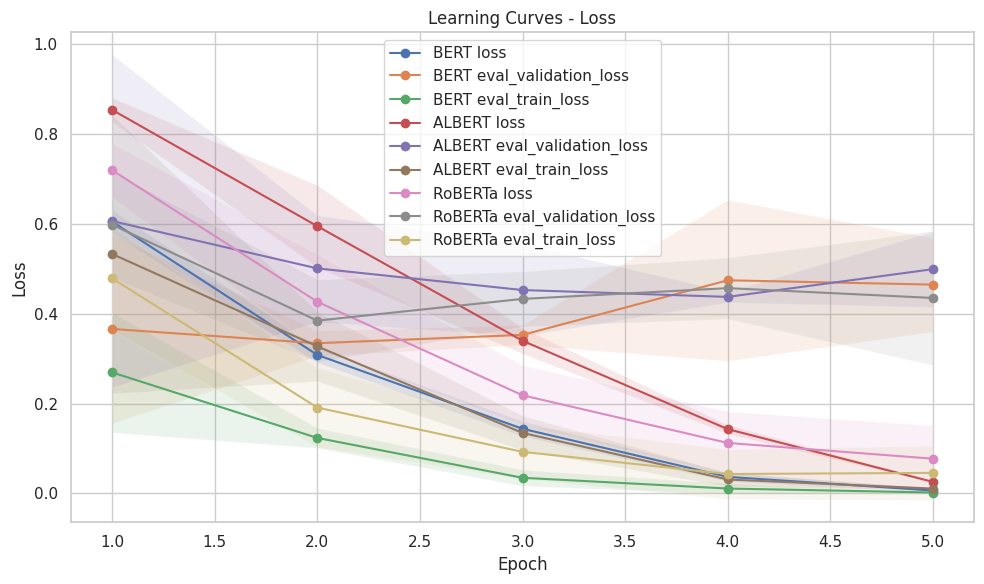

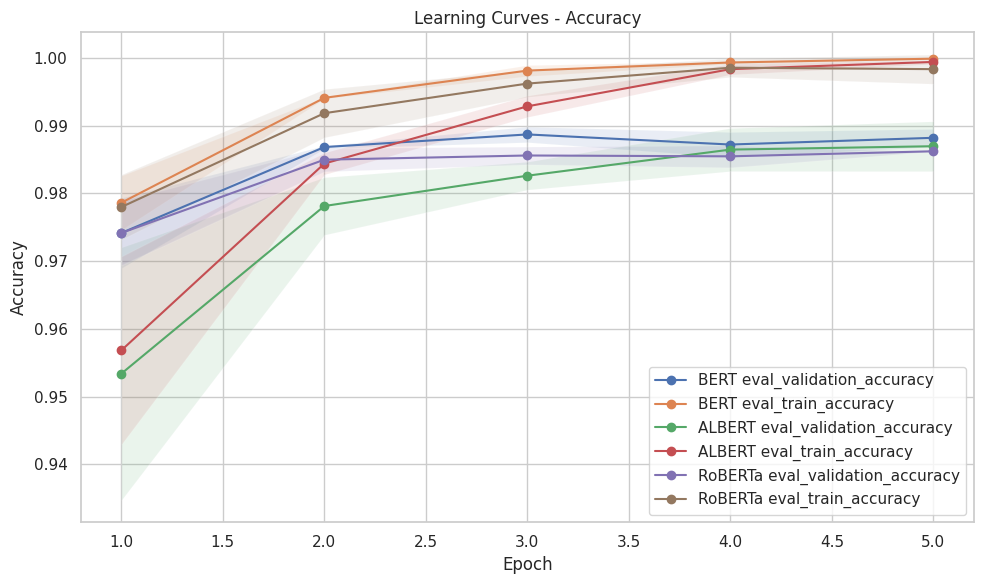

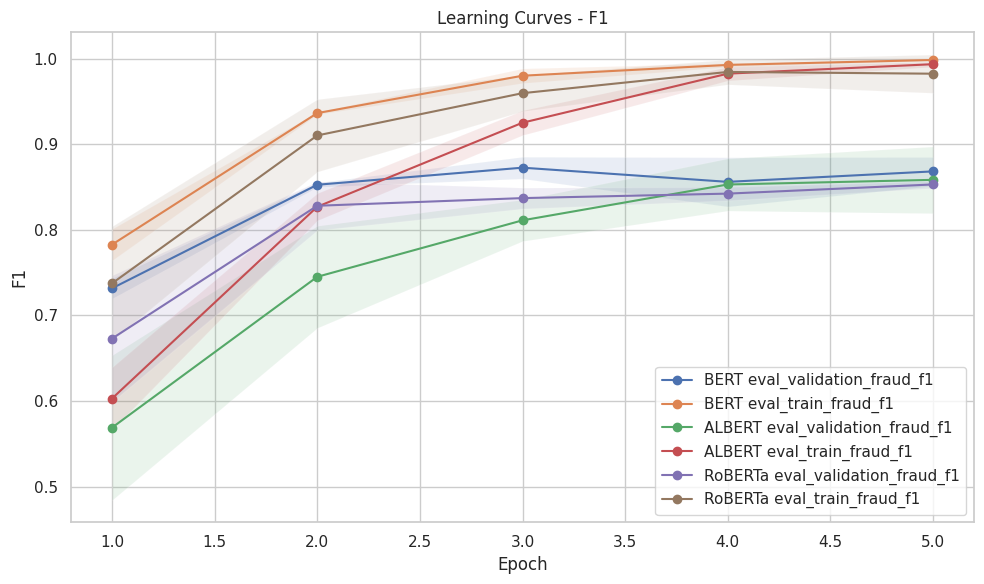

In [25]:
def normalize_history_frame(history_df: pd.DataFrame, model_label: str, seed: int) -> pd.DataFrame:
    normalized = history_df.copy()
    normalized["model_label"] = model_label
    normalized["seed"] = seed
    return normalized


def load_training_histories() -> pd.DataFrame:
    frames = []
    for seed in EXPERIMENT_SEEDS:
        for model_label in MODEL_REGISTRY:
            history_path = run_dir_for(seed, model_label) / "training_history.csv"
            if history_path.exists():
                frames.append(normalize_history_frame(pd.read_csv(history_path), model_label, seed))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_learning_curves() -> None:
    history_df = load_training_histories()
    if history_df.empty:
        print("No training history files found.")
        return
    curve_specs = [
        ("loss", ["loss", "eval_validation_loss", "eval_train_loss"], "learning_curves_loss_mean_std.png"),
        ("accuracy", ["eval_validation_accuracy", "eval_train_accuracy"], "learning_curves_accuracy_mean_std.png"),
        ("f1", ["eval_validation_fraud_f1", "eval_train_fraud_f1"], "learning_curves_f1_mean_std.png"),
    ]
    for title, candidate_columns, filename in curve_specs:
        available_columns = [column for column in candidate_columns if column in history_df.columns]
        if not available_columns:
            print(f"No columns found for {title}: {candidate_columns}")
            continue
        fig, ax = plt.subplots(figsize=(10, 6))
        for model_label in MODEL_REGISTRY:
            model_history = history_df[history_df["model_label"] == model_label]
            for column in available_columns:
                curve = model_history.groupby("epoch")[column].agg(["mean", "std"]).dropna()
                if curve.empty:
                    continue
                ax.plot(curve.index, curve["mean"], marker="o", label=f"{model_label} {column}")
                ax.fill_between(curve.index, curve["mean"] - curve["std"].fillna(0), curve["mean"] + curve["std"].fillna(0), alpha=0.12)
        ax.set_title(f"Learning Curves - {title.title()}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title.title())
        ax.legend()
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / filename, dpi=200)
        plt.show()


plot_learning_curves()


## 14. ROC and PR Curve Visualization

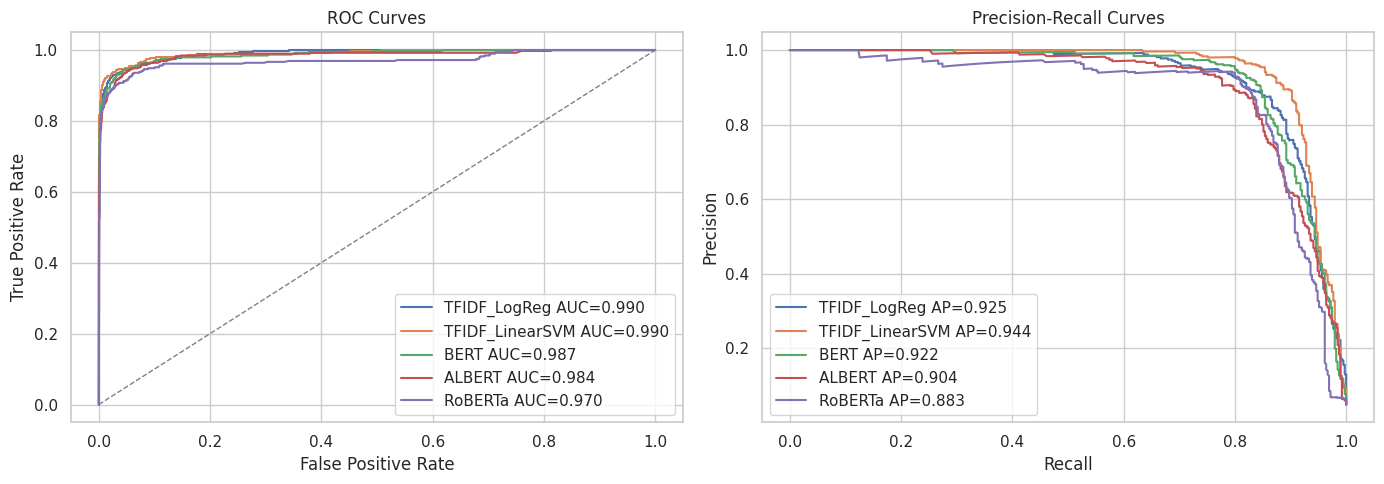

In [26]:
def load_prediction_frames() -> pd.DataFrame:
    frames = []
    for seed in EXPERIMENT_SEEDS:
        for model_label in get_all_model_labels():
            prediction_path = run_dir_for(seed, model_label) / "predictions.csv"
            if prediction_path.exists():
                frame = pd.read_csv(prediction_path)
                frame["seed"] = seed
                frame["model_label"] = model_label
                frame["model_group"] = model_group_for(model_label)
                frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_roc_pr_curves() -> None:
    predictions_df = load_prediction_frames()
    if predictions_df.empty:
        print("No prediction files found.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model_label in get_all_model_labels():
        model_predictions = predictions_df[predictions_df["model_label"] == model_label]
        if model_predictions.empty:
            continue
        labels = model_predictions["true_label"].values
        scores = model_predictions["fraud_score"].values
        fpr, tpr, _ = roc_curve(labels, scores)
        precision, recall, _ = precision_recall_curve(labels, scores)
        axes[0].plot(fpr, tpr, label=f"{model_label} AUC={roc_auc_score(labels, scores):.3f}")
        axes[1].plot(recall, precision, label=f"{model_label} AP={average_precision_score(labels, scores):.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[0].set_title("ROC Curves")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()
    axes[1].set_title("Precision-Recall Curves")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "roc_curves.png", dpi=200)
    fig.savefig(FIGURES_DIR / "pr_curves.png", dpi=200)
    plt.show()


plot_roc_pr_curves()


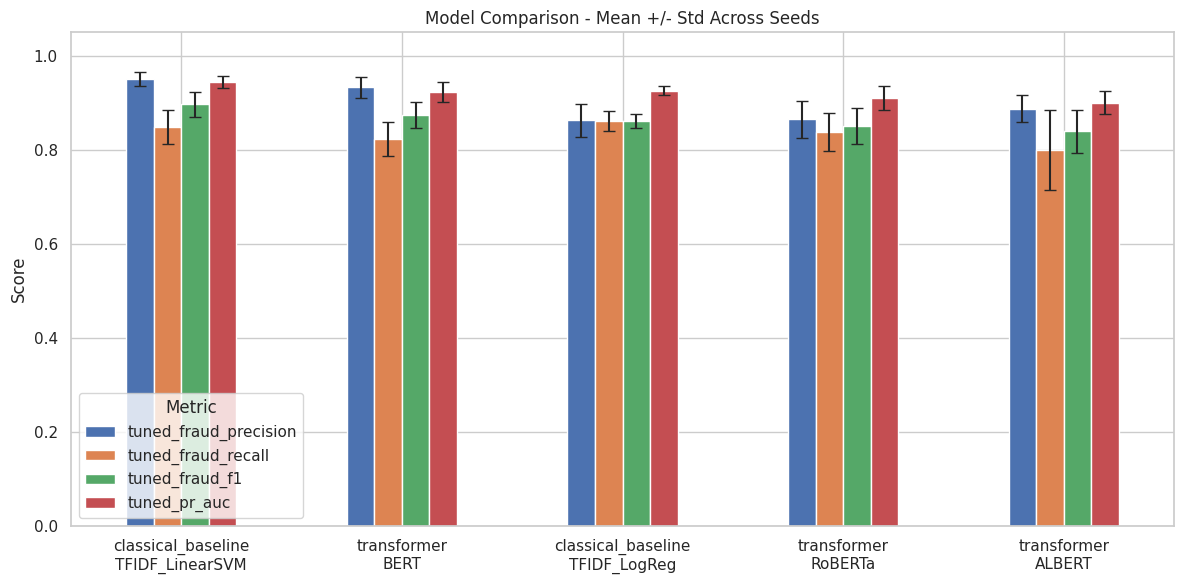

In [27]:
def plot_model_comparison(mean_std_df: pd.DataFrame) -> None:
    if mean_std_df.empty:
        print("No aggregate metrics found.")
        return
    metrics = ["tuned_fraud_precision", "tuned_fraud_recall", "tuned_fraud_f1", "tuned_pr_auc"]
    means = mean_std_df.loc[:, [(metric, "mean") for metric in metrics]]
    stds = mean_std_df.loc[:, [(metric, "std") for metric in metrics]]
    means.columns = metrics
    stds.columns = metrics
    plot_means = means.copy()
    plot_means.index = [
        f"{model_group}\n{model_label}" if isinstance(model_group, str) else str(model_label)
        for model_group, model_label in plot_means.index
    ]
    plot_stds = stds.copy()
    plot_stds.index = plot_means.index
    ax = plot_means.plot(kind="bar", yerr=plot_stds, figsize=(12, 6), capsize=4)
    ax.set_title("Model Comparison - Mean +/- Std Across Seeds")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Metric")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_comparison_mean_std.png", dpi=200)
    plt.show()


plot_model_comparison(mean_std_by_model)


## 15. Error Analysis and Subgroup Analysis

In [28]:
def compare_model_error_cases(predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    required_models = set(MODEL_REGISTRY)
    for seed, seed_df in predictions_df.groupby("seed"):
        for job_id, job_df in seed_df.groupby("job_id"):
            if not required_models.issubset(set(job_df["model_label"])):
                continue
            wide = job_df.set_index("model_label")
            correctness = wide["true_label"] == wide["predicted_label"]
            base = wide.loc["ALBERT"].to_dict()
            base.update({"seed": seed, "job_id": job_id})
            if correctness.get("ALBERT", False) and (not correctness.get("BERT", True) or not correctness.get("RoBERTa", True)):
                row = dict(base)
                row["case_type"] = "albert_correct_other_wrong"
                rows.append(row)
            if not correctness.any():
                row = dict(base)
                row["case_type"] = "all_models_wrong"
                rows.append(row)
    return pd.DataFrame(rows)


def build_error_analysis() -> pd.DataFrame:
    predictions_df = load_prediction_frames()
    if predictions_df.empty:
        empty = pd.DataFrame()
        empty.to_csv(SUMMARY_DIR / "error_cases.csv", index=False)
        return empty
    rows = []
    for model_label in MODEL_REGISTRY:
        model_predictions = predictions_df[predictions_df["model_label"] == model_label]
        high_conf_fp = model_predictions[model_predictions["error_type"] == "FP"].nlargest(10, "fraud_score")
        high_conf_fn = model_predictions[model_predictions["error_type"] == "FN"].nsmallest(10, "fraud_score")
        for case_type, frame in [("high_confidence_fp", high_conf_fp), ("high_confidence_fn", high_conf_fn)]:
            if frame.empty:
                continue
            case_frame = frame.copy()
            case_frame["case_type"] = case_type
            rows.append(case_frame)
    comparison_cases = compare_model_error_cases(predictions_df)
    if not comparison_cases.empty:
        rows.append(comparison_cases)
    error_cases_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    error_cases_df.to_csv(SUMMARY_DIR / "error_cases.csv", index=False)
    return error_cases_df


def build_error_summary_by_model() -> pd.DataFrame:
    predictions_df = load_prediction_frames()
    if predictions_df.empty:
        empty = pd.DataFrame()
        empty.to_csv(SUMMARY_DIR / "error_summary_by_model.csv", index=False)
        return empty
    summary_df = (
        predictions_df.groupby(["model_group", "model_label", "error_type"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for column in ["FP", "FN", "correct"]:
        if column not in summary_df.columns:
            summary_df[column] = 0
    summary_df["total"] = summary_df[["FP", "FN", "correct"]].sum(axis=1)
    summary_df.to_csv(SUMMARY_DIR / "error_summary_by_model.csv", index=False)
    return summary_df


error_cases_df = build_error_analysis()
display(error_cases_df.head(20))

error_summary_by_model = build_error_summary_by_model()
display(error_summary_by_model)


,job_id,title,company_profile,description,requirements,benefits,fraudulent,true_label,fraud_score,fraud_probability,score_type,threshold,predicted_label,error_type,seed,model_label,model_group,case_type
0,6907,Administrative Assistant,NaN,"Open/close office, manage phones, greet and di...",Must take PRIDE in work tasksSuperb Customer S...,Compensation is determined on an individual ba...,0,0,0.999886,0.999886,probability,0.33,1,FP,123,BERT,transformer,high_confidence_fp
1,17860,Immediate Requirement: iOS Developer for Qatar,NaN,Greetings from VAM SYSTEMS…..VAM SYSTEMS is a ...,"iOS programming “Objective – C “, C++#URL_01a...",NaN,0,0,0.999841,0.999841,probability,0.10,1,FP,2024,BERT,transformer,high_confidence_fp
2,16971,Customer Service - Work From Home,NaN,Do you have 1+ year of customer service/call c...,Job Requirements/Qualifications:* 1+ year of C...,* 1099 Contract * Work From Home* Average of $...,0,0,0.999732,0.999732,probability,0.72,1,FP,42,BERT,transformer,high_confidence_fp
3,6907,Administrative Assistant,NaN,"Open/close office, manage phones, greet and di...",Must take PRIDE in work tasksSuperb Customer S...,Compensation is determined on an individual ba...,0,0,0.999729,0.999729,probability,0.10,1,FP,2024,BERT,transformer,high_confidence_fp
4,537,Part-Time Administrative/Data Entry I,NaN,As Part Time Administrative Assistant/ Data En...,Candidates must possess the following skills/q...,The selected candidate will benefit from the f...,0,0,0.999500,0.999500,probability,0.33,1,FP,123,BERT,transformer,high_confidence_fp
5,1200,Casual/Part-Time Position,NaN,Our International Company is seeking an active...,Main requirements:- free time presence;- Compu...,Working days - from Monday to Friday;Working t...,0,0,0.999433,0.999433,probability,0.10,1,FP,2024,BERT,transformer,high_confidence_fp
6,537,Part-Time Administrative/Data Entry I,NaN,As Part Time Administrative Assistant/ Data En...,Candidates must possess the following skills/q...,The selected candidate will benefit from the f...,0,0,0.999413,0.999413,probability,0.10,1,FP,2024,BERT,transformer,high_confidence_fp
7,38,PROJECT MANAGER,NaN,we are looking for a Project Manager. The Proj...,NaN,NaN,0,0,0.999066,0.999066,probability,0.10,1,FP,2024,BERT,transformer,high_confidence_fp
8,5448,Customer Service Agent,NaN,Position: Call Center Customer Service AgentDo...,What are the basic requirements?- Matric or eq...,NaN,0,0,0.998387,0.998387,probability,0.33,1,FP,123,BERT,transformer,high_confidence_fp
9,537,Part-Time Administrative/Data Entry I,NaN,As Part Time Administrative Assistant/ Data En...,Candidates must possess the following skills/q...,The selected candidate will benefit from the f...,0,0,0.998016,0.998016,probability,0.72,1,FP,42,BERT,transformer,high_confidence_fp


error_type,model_group,model_label,FN,FP,correct,total
0,classical_baseline,TFIDF_LinearSVM,59,17,7970,8046
1,classical_baseline,TFIDF_LogReg,54,54,7938,8046
2,transformer,ALBERT,78,40,7928,8046
3,transformer,BERT,69,23,7954,8046
4,transformer,RoBERTa,63,51,7932,8046


In [29]:
def attach_subgroup_columns(predictions_df: pd.DataFrame) -> pd.DataFrame:
    available_subgroups = [column for column in SUBGROUP_COLUMNS if column in df.columns]
    subgroup_source = df[["job_id"] + available_subgroups].copy()
    return predictions_df.merge(subgroup_source, on="job_id", how="left")


def build_subgroup_metrics() -> pd.DataFrame:
    predictions_df = load_prediction_frames()
    if predictions_df.empty:
        empty = pd.DataFrame()
        empty.to_csv(SUMMARY_DIR / "subgroup_metrics.csv", index=False)
        return empty
    predictions_df = attach_subgroup_columns(predictions_df)
    rows = []
    for model_label in MODEL_REGISTRY:
        model_predictions = predictions_df[predictions_df["model_label"] == model_label]
        for subgroup_column in [column for column in SUBGROUP_COLUMNS if column in model_predictions.columns]:
            for subgroup_value, subgroup_df in model_predictions.groupby(subgroup_column, dropna=False):
                labels = subgroup_df["true_label"].astype(int).values
                preds = subgroup_df["predicted_label"].astype(int).values
                rows.append(
                    {
                        "model_label": model_label,
                        "subgroup_column": subgroup_column,
                        "subgroup_value": str(subgroup_value),
                        "sample_count": int(len(subgroup_df)),
                        "fraud_count": int(labels.sum()),
                        "fraud_precision": float(precision_score(labels, preds, zero_division=0)),
                        "fraud_recall": float(recall_score(labels, preds, zero_division=0)),
                        "fraud_f1": float(f1_score(labels, preds, zero_division=0)),
                    }
                )
    subgroup_metrics_df = pd.DataFrame(rows)
    subgroup_metrics_df.to_csv(SUMMARY_DIR / "subgroup_metrics.csv", index=False)
    return subgroup_metrics_df


subgroup_metrics_df = build_subgroup_metrics()
display(subgroup_metrics_df.head(20))


,model_label,subgroup_column,subgroup_value,sample_count,fraud_count,fraud_precision,fraud_recall,fraud_f1
0,BERT,telecommuting,0,7670,361,0.931034,0.822715,0.873529
1,BERT,telecommuting,1,376,29,0.960000,0.827586,0.888889
2,BERT,has_company_logo,0,1630,242,0.905941,0.756198,0.824324
3,BERT,has_company_logo,1,6416,148,0.971831,0.932432,0.951724
4,BERT,has_questions,0,4110,261,0.951542,0.827586,0.885246
5,BERT,has_questions,1,3936,129,0.897436,0.813953,0.853659
6,BERT,employment_type,Contract,667,17,0.875000,0.411765,0.560000
7,BERT,employment_type,Full-time,5240,230,0.944186,0.882609,0.912360
8,BERT,employment_type,Other,90,4,1.000000,0.500000,0.666667
9,BERT,employment_type,Part-time,396,36,0.896552,0.722222,0.800000


## 16. Paper Tables and Figures

In [30]:
table_1_dataset_statistics = pd.DataFrame(
    [
        {
            "total_samples": data_profile["rows"],
            "legitimate_samples": data_profile["label_counts"].get("0", 0),
            "fraudulent_samples": data_profile["label_counts"].get("1", 0),
            "fraud_rate": data_profile["fraud_rate"],
        }
    ]
)
table_1_dataset_statistics.to_csv(SUMMARY_DIR / "table_1_dataset_statistics.csv", index=False)

table_2_model_performance = mean_std_by_model.copy() if "mean_std_by_model" in globals() else pd.DataFrame()
table_2_model_performance.to_csv(SUMMARY_DIR / "table_2_model_performance.csv")

table_3_statistical_comparison = significance_tests_df.copy() if "significance_tests_df" in globals() else pd.DataFrame()
table_3_statistical_comparison.to_csv(SUMMARY_DIR / "table_3_statistical_comparison.csv", index=False)

table_4_runtime = all_runs_df[["seed", "model_label", "runtime_minutes"]].copy() if "all_runs_df" in globals() and not all_runs_df.empty else pd.DataFrame()
table_4_runtime.to_csv(SUMMARY_DIR / "table_4_runtime.csv", index=False)


def build_deployment_readiness_table(all_runs_df: pd.DataFrame) -> pd.DataFrame:
    if all_runs_df.empty:
        empty = pd.DataFrame()
        empty.to_csv(SUMMARY_DIR / "deployment_readiness.csv", index=False)
        return empty
    rows = []
    for _, row in all_runs_df.iterrows():
        runtime = read_json(Path(row["run_dir"]) / "runtime.json")
        model_dir = Path(row["run_dir"]) / "model"
        rows.append(
            {
                "seed": row["seed"],
                "model_group": row["model_group"],
                "model_label": row["model_label"],
                "selected_threshold": row["tuned_threshold"],
                "tuned_fraud_f1": row["tuned_fraud_f1"],
                "tuned_pr_auc": row["tuned_pr_auc"],
                "tuned_roc_auc": row["tuned_roc_auc"],
                "runtime_minutes": row["runtime_minutes"],
                "inference_latency_ms_per_sample_mean": runtime.get("inference_latency_ms_per_sample_mean"),
                "inference_latency_ms_per_sample_std": runtime.get("inference_latency_ms_per_sample_std"),
                "model_size_mb": compute_directory_size_mb(model_dir),
                "export_eligible": bool(is_transformer_model(row["model_label"])),
            }
        )
    readiness_df = pd.DataFrame(rows)
    readiness_df.to_csv(SUMMARY_DIR / "deployment_readiness.csv", index=False)
    return readiness_df


deployment_readiness_df = build_deployment_readiness_table(all_runs_df)
display(deployment_readiness_df)

thresholds_by_model = (
    all_runs_df[["seed", "model_group", "model_label", "tuned_threshold", "score_type"]].copy()
    if "all_runs_df" in globals() and not all_runs_df.empty
    else pd.DataFrame()
)
thresholds_by_model.to_csv(SUMMARY_DIR / "thresholds_by_model.csv", index=False)
display(thresholds_by_model.head())

display(table_1_dataset_statistics)
display(table_2_model_performance)
display(table_3_statistical_comparison.head())
display(table_4_runtime.head())


,seed,model_group,model_label,selected_threshold,tuned_fraud_f1,tuned_pr_auc,tuned_roc_auc,runtime_minutes,inference_latency_ms_per_sample_mean,inference_latency_ms_per_sample_std,model_size_mb,export_eligible
0,42,classical_baseline,TFIDF_LogReg,0.590000,0.877470,0.931171,0.989146,0.256207,0.571527,0.017237,NaN,False
1,42,classical_baseline,TFIDF_LinearSVM,0.000000,0.919355,0.947907,0.991087,0.261167,0.560207,0.030452,NaN,False
2,42,transformer,BERT,0.720000,0.888889,0.944155,0.991976,27.204615,5.489639,0.043431,418.354582,True
3,42,transformer,ALBERT,0.230000,0.855967,0.914834,0.990425,32.496909,9.286148,0.698539,46.451861,True
4,42,transformer,RoBERTa,0.210000,0.869231,0.931505,0.992906,28.550983,5.089996,0.068192,478.914220,True
5,123,classical_baseline,TFIDF_LogReg,0.530000,0.846154,0.914307,0.988663,0.295016,0.809965,0.229308,NaN,False
6,123,classical_baseline,TFIDF_LinearSVM,-0.032525,0.867769,0.931213,0.988868,0.295976,0.684092,0.044596,NaN,False
7,123,transformer,BERT,0.330000,0.842975,0.901447,0.986213,29.026347,6.898553,0.936143,418.354582,True
8,123,transformer,ALBERT,0.900000,0.788136,0.873064,0.969861,32.770155,9.568055,0.722535,46.451861,True
9,123,transformer,RoBERTa,0.180000,0.807843,0.883281,0.979457,21.934262,5.336018,0.256001,478.914220,True


,seed,model_group,model_label,tuned_threshold,score_type
0,42,classical_baseline,TFIDF_LogReg,0.59,probability
1,42,classical_baseline,TFIDF_LinearSVM,0.00,decision_function
2,42,transformer,BERT,0.72,probability
3,42,transformer,ALBERT,0.23,probability
4,42,transformer,RoBERTa,0.21,probability


,total_samples,legitimate_samples,fraudulent_samples,fraud_rate
0,17880,17014,866,0.048434


tuned_accuracy            \
                                             mean       std   
model_group        model_label                                
classical_baseline TFIDF_LinearSVM       0.990554  0.002278   
transformer        BERT                  0.988566  0.002368   
classical_baseline TFIDF_LogReg          0.986577  0.001709   
transformer        RoBERTa               0.985831  0.003596   
                   ALBERT                0.985334  0.003464   

                                   tuned_fraud_precision            \
                                                    mean       std   
model_group        model_label                                       
classical_baseline TFIDF_LinearSVM              0.950918  0.014382   
transformer        BERT                         0.933080  0.022521   
classical_baseline TFIDF_LogReg                 0.862670  0.034606   
transformer        RoBERTa                      0.865223  0.039373   
                   ALBERT                       0.887458  0.029187   

                                   tuned_fraud_recall            \
                                                 mean       std   
model_group        model_label                                    
classical_baseline TFIDF_LinearSVM           0.848718  0.036352   
transformer        BERT                      0.823077  0.035251   
classical_baseline TFIDF_LogReg              0.861538  0.020352   
transformer        RoBERTa                   0.838462  0.040704   
                   ALBERT                    0.800000  0.084615   

                                   tuned_fraud_f1           tuned_macro_f1  \
                                             mean       std           mean   
model_group        model_label                                               
classical_baseline TFIDF_LinearSVM       0.896783  0.026390       0.945917   
transformer        BERT                  0.874477  0.027314       0.934243   
classical_baseline TFIDF_LogReg          0.861682  0.015660       0.927314   
transformer        RoBERTa               0.851515  0.038044       0.922038   
                   ALBERT                0.839542  0.045476       0.915929   

                                             tuned_balanced_accuracy  \
                                         std                    mean   
model_group        model_label                                         
classical_baseline TFIDF_LinearSVM  0.013790                0.923249   
transformer        BERT             0.014275                0.910036   
classical_baseline TFIDF_LogReg     0.008274                0.927243   
transformer        RoBERTa          0.019965                0.915900   
                   ALBERT           0.023633                0.897388   

                                             tuned_specificity            \
                                         std              mean       std   
model_group        model_label                                             
classical_baseline TFIDF_LinearSVM  0.018439          0.997780  0.000599   
transformer        BERT             0.017908          0.996996  0.000986   
classical_baseline TFIDF_LogReg     0.009699          0.992947  0.002073   
transformer        RoBERTa          0.021102          0.993339  0.001959   
                   ALBERT           0.041824          0.994775  0.001767   

                                   tuned_roc_auc           tuned_pr_auc  \
                                            mean       std         mean   
model_group        model_label                                            
classical_baseline TFIDF_LinearSVM      0.990355  0.001288     0.944943   
transformer        BERT                 0.989460  0.002950     0.923168   
classical_baseline TFIDF_LogReg         0.990290  0.002412     0.926093   
transformer        RoBERTa              0.987202  0.006953     0.910607   
                   ALBERT               0.984866  0.013139     0.900660   

                    

,metric,observed_difference,ci_lower,ci_upper,p_value_approx,seed,model_a,model_b
0,fraud_f1,-0.041884,-0.077182,-0.014403,0.002,42,TFIDF_LogReg,TFIDF_LinearSVM
1,pr_auc,-0.016736,-0.030441,-0.005475,0.000,42,TFIDF_LogReg,TFIDF_LinearSVM
2,fraud_f1,-0.011419,-0.055069,0.030166,0.596,42,TFIDF_LogReg,BERT
3,pr_auc,-0.012984,-0.041449,0.017253,0.324,42,TFIDF_LogReg,BERT
4,fraud_f1,0.021503,-0.025897,0.069308,0.362,42,TFIDF_LogReg,ALBERT


,seed,model_label,runtime_minutes
0,42,TFIDF_LogReg,0.256207
1,42,TFIDF_LinearSVM,0.261167
2,42,BERT,27.204615
3,42,ALBERT,32.496909
4,42,RoBERTa,28.550983


## 17. Export Best Model

In [31]:
def select_best_completed_run(all_runs_df: pd.DataFrame) -> pd.Series:
    if all_runs_df.empty:
        raise ValueError("No completed runs available for best model export.")
    transformer_runs = all_runs_df[all_runs_df["model_label"].isin(MODEL_REGISTRY)].copy()
    if transformer_runs.empty:
        raise ValueError("No completed Transformer runs available for best model export.")
    return transformer_runs.sort_values(
        ["tuned_fraud_f1", "tuned_pr_auc", "tuned_fraud_recall"],
        ascending=False,
    ).iloc[0]


def export_best_model() -> dict:
    best_run = select_best_completed_run(all_runs_df)
    source_model_dir = Path(best_run["run_dir"]) / "model"
    if not source_model_dir.exists():
        raise FileNotFoundError(f"Best run model directory not found: {source_model_dir}")
    if BEST_MODEL_DIR.exists():
        shutil.rmtree(BEST_MODEL_DIR)
    shutil.copytree(source_model_dir, BEST_MODEL_DIR)
    model_label = best_run["model_label"]
    meta = {
        "model_name": model_label,
        "hf_model_id": MODEL_REGISTRY[model_label],
        "selected_threshold": float(best_run["tuned_threshold"]),
        "selection_metric": "tuned_fraud_f1",
        "selected_seed": int(best_run["seed"]),
        "metrics": {
            "accuracy": float(best_run["tuned_accuracy"]),
            "precision": float(best_run["tuned_fraud_precision"]),
            "recall": float(best_run["tuned_fraud_recall"]),
            "f1": float(best_run["tuned_fraud_f1"]),
            "macro_f1": float(best_run["tuned_macro_f1"]),
            "balanced_accuracy": float(best_run["tuned_balanced_accuracy"]),
            "specificity": float(best_run["tuned_specificity"]),
            "pr_auc": float(best_run["tuned_pr_auc"]),
            "roc_auc": float(best_run["tuned_roc_auc"]),
        },
        "config": CONFIG,
        "preprocessing": {
            "text_columns": TEXT_COLUMNS,
            "cleaning": "html_unescape_strip_html_remove_urls_lowercase_normalize_whitespace",
        },
        "artifact_path": str(best_run["run_dir"]),
        "multi_seed_summary_path": str(SUMMARY_DIR / "mean_std_by_model.csv"),
        "deployment_readiness_path": str(SUMMARY_DIR / "deployment_readiness.csv"),
        "exported_at": datetime.now().isoformat(),
    }
    write_json(BEST_MODEL_DIR / "model_meta.json", meta)
    return meta


if "all_runs_df" in globals() and not all_runs_df.empty:
    best_model_meta = export_best_model()
    display(best_model_meta)
else:
    print("No completed runs available; skipping best_model export.")


{'model_name': 'BERT',
 'hf_model_id': 'bert-base-uncased',
 'selected_threshold': 0.1,
 'selection_metric': 'tuned_fraud_f1',
 'selected_seed': 2024,
 'metrics': {'accuracy': 0.9899328859060402,
  'precision': 0.9327731092436975,
  'recall': 0.8538461538461538,
  'f1': 0.891566265060241,
  'macro_f1': 0.9431438363424371,
  'balanced_accuracy': 0.9253556788039546,
  'specificity': 0.9968652037617555,
  'pr_auc': 0.9239014284200865,
  'roc_auc': 0.9901901977333012},
 'config': {'max_len': 256,
  'batch_size': 16,
  'gradient_accumulation_steps': 1,
  'epochs': 5,
  'early_stopping_patience': 2,
  'learning_rate': 2e-05,
  'weight_decay': 0.01,
  'warmup_ratio': 0.1,
  'test_size': 0.15,
  'val_size': 0.15,
  'threshold_grid': [0.1,
   0.11,
   0.12,
   0.13,
   0.14,
   0.15,
   0.16,
   0.17,
   0.18,
   0.19,
   0.2,
   0.21,
   0.22,
   0.23,
   0.24,
   0.25,
   0.26,
   0.27,
   0.28,
   0.29,
   0.3,
   0.31,
   0.32,
   0.33,
   0.34,
   0.35,
   0.36,
   0.37,
   0.38,
   0.39,


## 18. Colab Drive Backup

In [32]:
def backup_artifacts_to_drive() -> None:
    if not running_in_colab():
        print("Not running in Google Colab; skipping Drive backup.")
        return
    from google.colab import drive

    drive.mount("/content/drive")
    backup_root = Path("/content/drive/MyDrive/job_scam_research_artifacts")
    backup_root.mkdir(parents=True, exist_ok=True)
    artifacts_zip = shutil.make_archive("job_scam_artifacts", "zip", str(ARTIFACT_DIR))
    shutil.copy(artifacts_zip, backup_root / "job_scam_artifacts.zip")
    if BEST_MODEL_DIR.exists():
        best_model_zip = shutil.make_archive("best_model", "zip", str(BEST_MODEL_DIR))
        shutil.copy(best_model_zip, backup_root / "best_model.zip")
    print(f"Backed up artifacts to {backup_root}")


backup_artifacts_to_drive()


Mounted at /content/drive
Backed up artifacts to /content/drive/MyDrive/job_scam_research_artifacts
